In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape


(891, 12)

In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

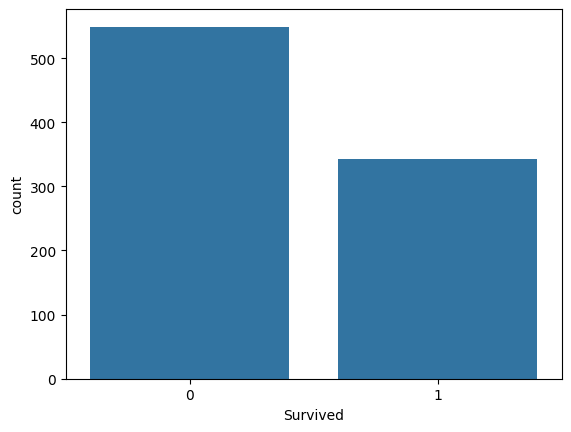

In [6]:
sns.countplot(x="Survived", data=df)
plt.show()

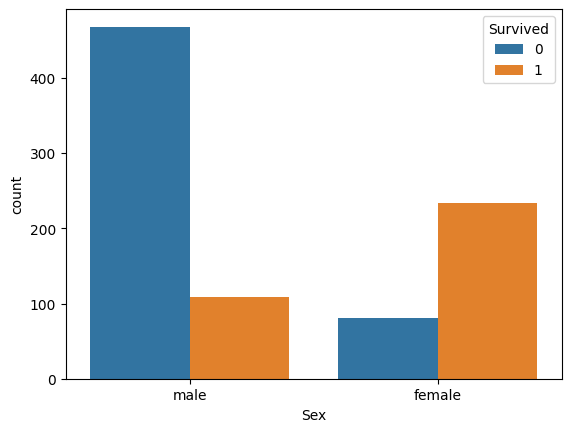

In [7]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.show()

In [8]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

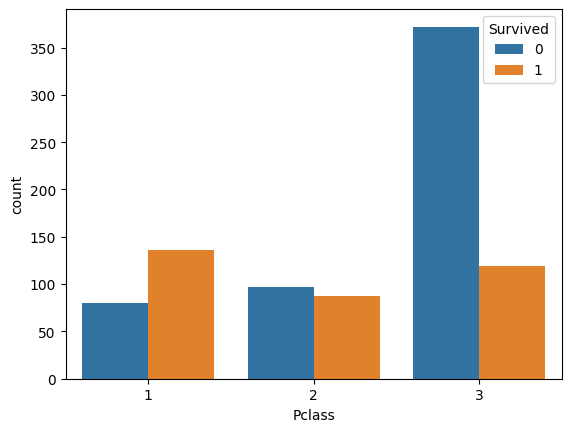

In [9]:
sns.countplot(x="Pclass", hue = "Survived" , data = df)
plt.show()

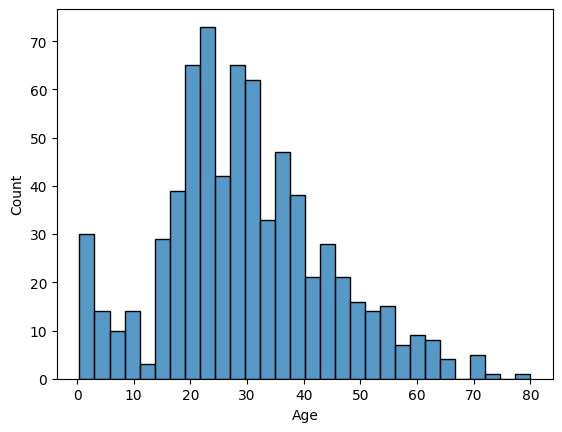

In [10]:
sns.histplot(df["Age"], bins =30)
plt.show()

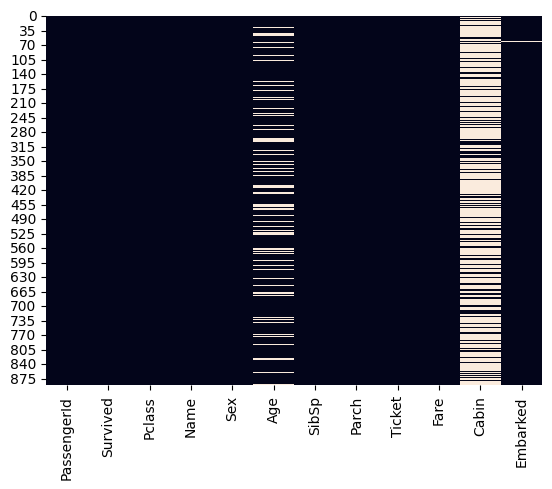

In [11]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

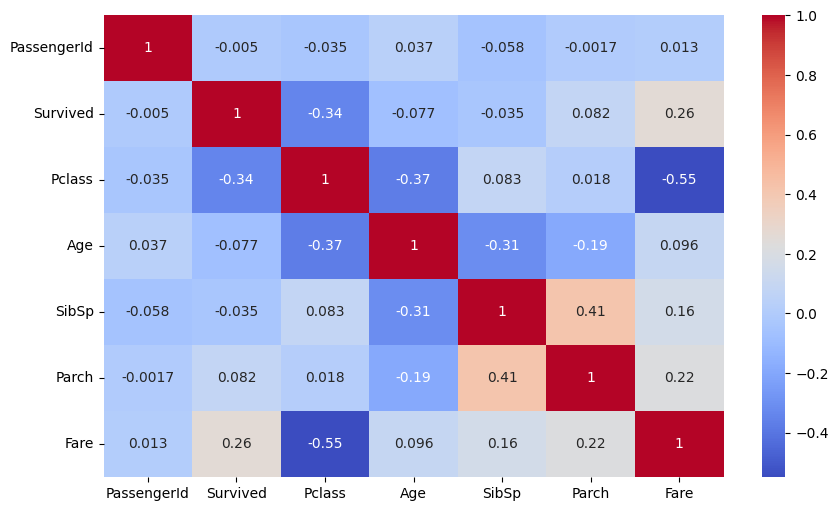

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

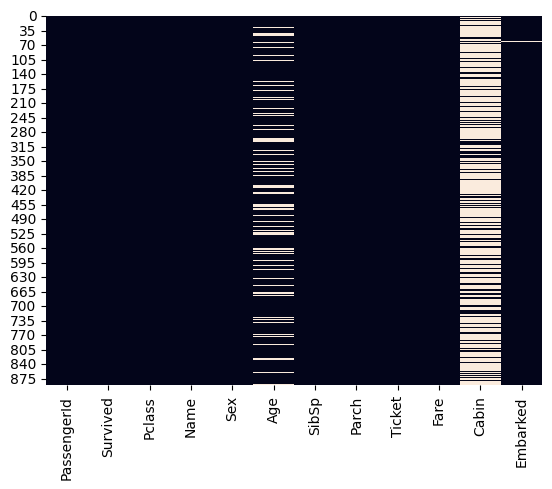

In [13]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [14]:
df = df.drop(["Cabin", "Name", "Ticket"], axis = 1)

In [15]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [16]:
age = df["Age"]
age.fillna(age.median(), inplace=True)
embarked = df["Embarked"]
embarked.fillna(embarked.mode()[0], inplace = True)

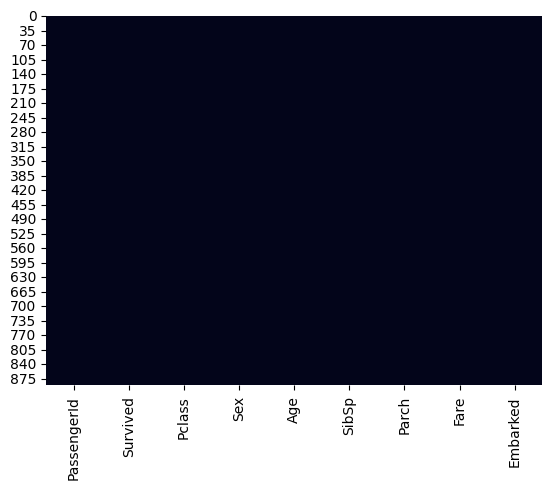

In [17]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [18]:
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

In [19]:
df.columns
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


In [20]:
features = df.drop("Survived", axis=1)
target = df["Survived"]

In [21]:
from sklearn.model_selection import train_test_split

f_train , f_test , t_train , t_test = train_test_split(features, target, test_size=0.2, 
                                                       random_state=42)

In [22]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

In [23]:
model.fit(f_train, t_train)

LogisticRegression(max_iter=1000)

In [24]:
t_pred = model.predict(f_test)

In [25]:
t_pred[:10]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

In [26]:
list(zip(features.columns, model.coef_[0]))

[('PassengerId', np.float64(0.0003537308422262029)),
 ('Pclass', np.float64(-0.9335749683063376)),
 ('Age', np.float64(-0.030570718818214014)),
 ('SibSp', np.float64(-0.2869863772260822)),
 ('Parch', np.float64(-0.11898880595862221)),
 ('Fare', np.float64(0.0026194087171332366)),
 ('Sex_male', np.float64(-2.6083343554458063)),
 ('Embarked_Q', np.float64(-0.10701593711495587)),
 ('Embarked_S', np.float64(-0.3993590058992696))]

0.8044692737430168


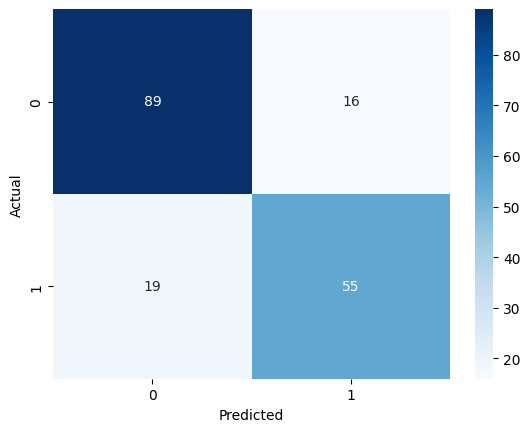

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(t_test, t_pred)
print(accuracy)

cm = confusion_matrix(t_test, t_pred)

sns.heatmap(cm, annot = True, cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print (classification_report(t_test, t_pred))

# **Trying to improve the performance using feature engineering and using another model** ***

In [28]:
df = df.drop("PassengerId", axis = 1)

In [29]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [30]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df = df.drop(["SibSp", "Parch"], axis=1)

In [31]:
features = df.drop("Survived", axis=1)
target = df["Survived"]

In [32]:
f_train , f_test , t_train , t_test = train_test_split(features, target, test_size=0.2, 
                                                       random_state=42)

In [33]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(f_train, t_train)

RandomForestClassifier(random_state=42)

In [34]:
t_pred = model.predict(f_test)

0.8324022346368715


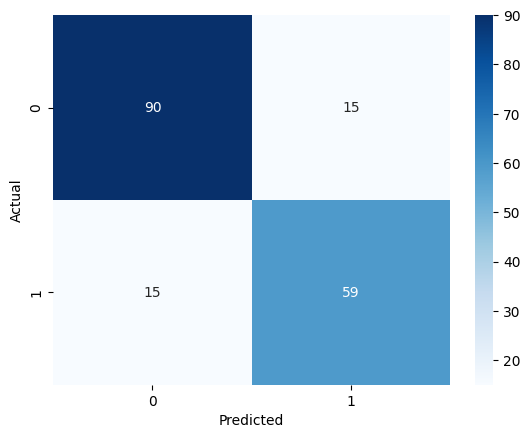

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       105
           1       0.80      0.80      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



In [35]:
accuracy = accuracy_score(t_test, t_pred)
print(accuracy)

cm = confusion_matrix(t_test, t_pred)

sns.heatmap(cm, annot = True, cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print (classification_report(t_test, t_pred))

In [36]:
feature_importance = pd.Series(model.feature_importances_, index=features.columns)
feature_importance.sort_values(ascending=False)

Fare          0.289451
Sex_male      0.260199
Age           0.258995
Pclass        0.079735
FamilySize    0.063876
Embarked_S    0.024975
IsAlone       0.013828
Embarked_Q    0.008940
dtype: float64